# So sánh Đa kiến trúc Mô hình Ước lượng Transfer Entropy (Pha U - Phần 2)

Notebook này thực hiện so sánh toàn diện giữa 5 họ kiến trúc mô hình:
1. **Classical MLP (128-128-64)**: Mạng sâu cơ bản.
2. **Small MLP (16-16)**: Mạng rút gọn siêu nhẹ.
3. **Temporal 1D-CNN**: Mạng tích chập 1 chiều bắt mối tương quan chuỗi.
4. **Pure VQC (6 Qubits, 4 Layers)**: Mạch lượng tử biến phân Data Re-uploading thuần.
5. **Hybrid Classical-Quantum (MLP + VQC)**: Mô hình lai trích xuất đặc trưng cổ điển kết hợp mạch lượng tử đa tương tác.

Tiêu chí đánh giá:
- Số lượng tham số (Trainable Parameters)
- Độ trễ suy luận (Inference Latency in ms/window)
- Độ lệch (Bias), Phương sai (Variance), và Sai số toàn phương trung bình (MSE)

In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Thiết lập JAVA_HOME cho JPype/IDTxl nếu cần
if 'JAVA_HOME' not in os.environ:
    os.environ['JAVA_HOME'] = r'C:\Users\Nguyen Dao Nam Hai\.jdks\ms-17.0.17'

# Tự động tìm project root
curr = Path.cwd()
root = curr if (curr / 'src').exists() else (curr.parent if (curr.parent / 'src').exists() else Path(r'D:\SPARC Lab\PQRST'))
os.chdir(root)
if str(root / 'src') not in sys.path:
    sys.path.insert(0, str(root / 'src'))
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from pqrst.evaluation.model_comparison import plot_architecture_comparison

In [2]:
# Đọc và hiển thị bảng so sánh đã benchmark
csv_path = 'results/tables/model_architecture_comparison.csv'
if Path(csv_path).exists():
    df_comp = pd.read_csv(csv_path)
    display(df_comp)
else:
    print(f'Chưa tìm thấy {csv_path}. Vui lòng chạy script benchmark trước.')

,model_name,architecture_type,n_params,avg_latency_ms,mean_te_estimate,bias,variance,mse
0,Classical MLP,Classical Deep NN,25473,11.192980,0.158754,-0.022641,0.002879,0.003248
1,Small MLP,Classical Lightweight,369,6.951610,0.151802,-0.029592,0.002870,0.003602
2,Temporal 1D-CNN,Classical Temporal CNN,2193,23.799070,0.011145,-0.170250,0.000005,0.028990
3,Pure VQC,Quantum Re-uploading,61,13197.301235,0.108705,-0.072689,0.015588,0.020092
4,Hybrid MLP+VQC,Hybrid Quantum-Classical,213,4799.110420,0.016051,-0.165344,0.000018,0.027355


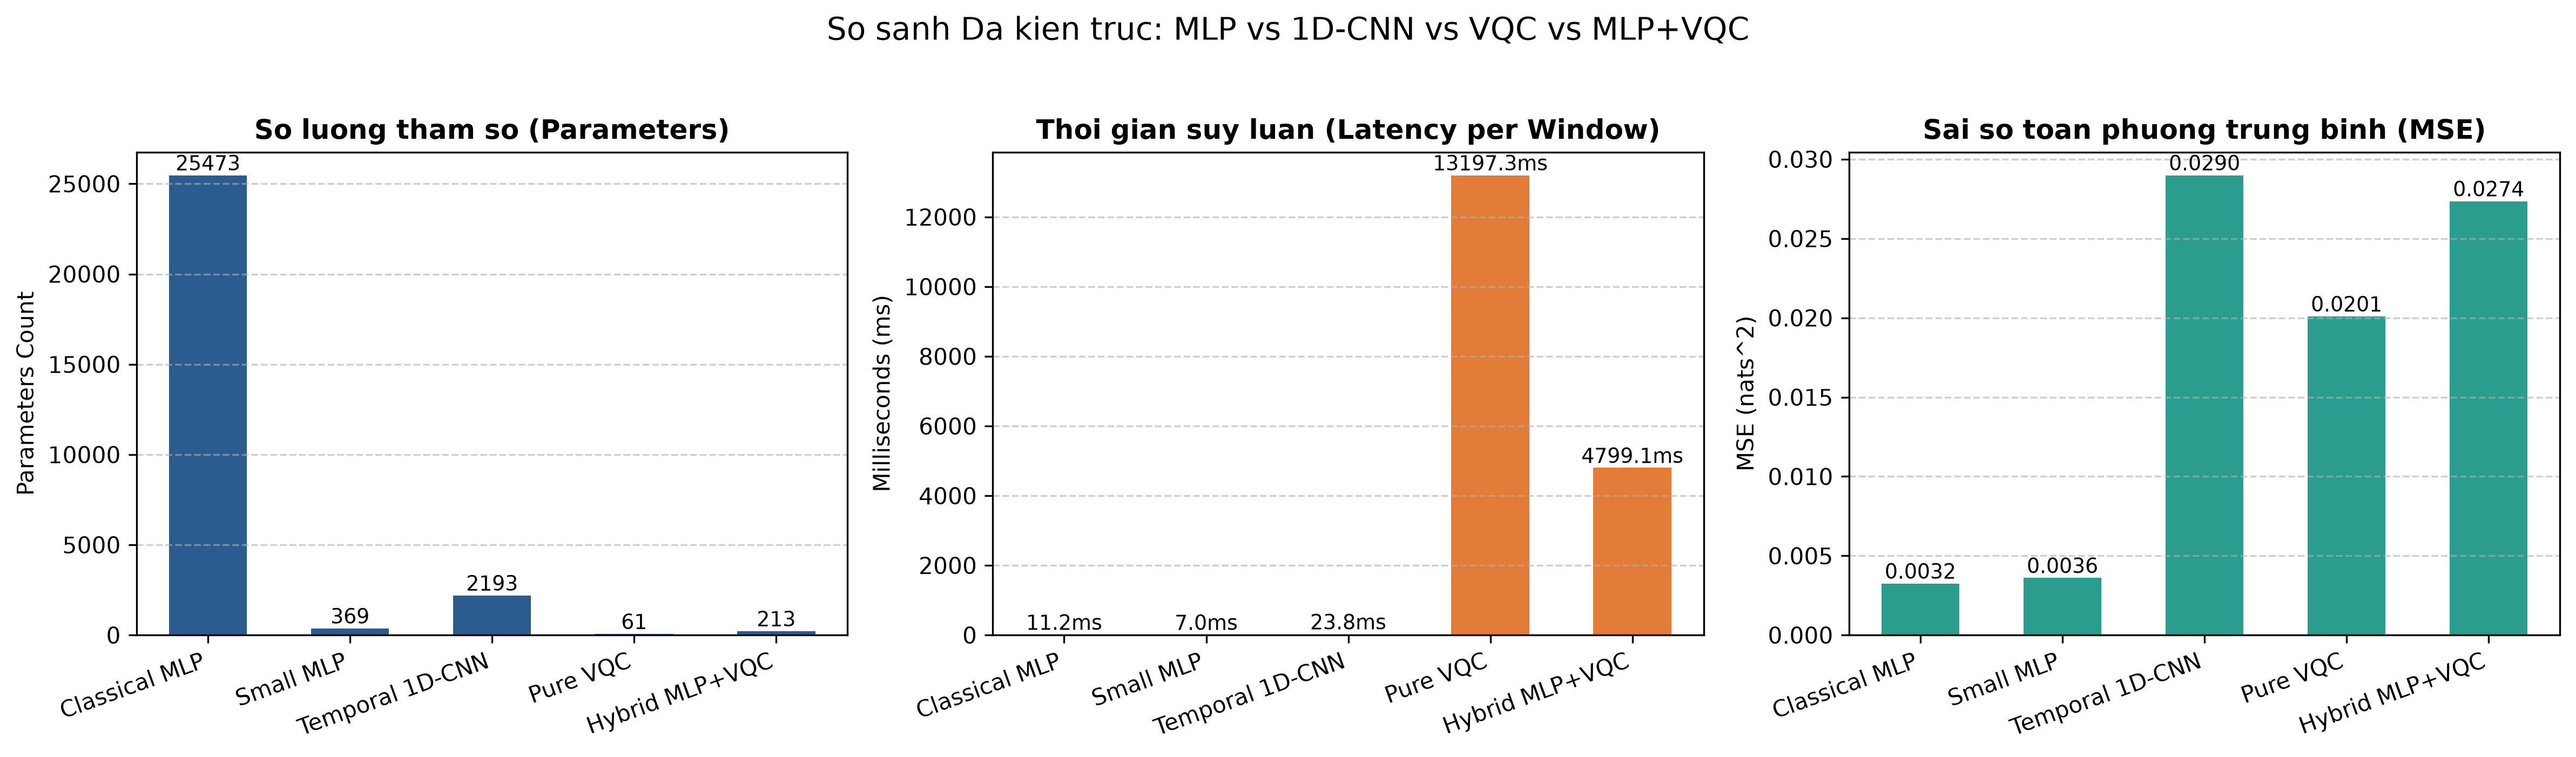

In [3]:
# Hiển thị biểu đồ 3 ô so sánh đa kiến trúc
fig_path = 'results/figures/model_architecture_comparison.png'
from IPython.display import Image
if Path(fig_path).exists():
    display(Image(fig_path))
else:
    print('Chưa có biểu đồ.')